# 1.Facebook GRAPH CONSTRUCTION

POST-POST HOMOPHILY GRAPH

In [1]:
import pandas as pd
import networkx as nx
from itertools import combinations

# =====================================================
# LOAD FACEBOOK GRAPH DATASET
# =====================================================

df = pd.read_csv(
    "../../data_preprocess/processed_data/graph_data/facebook_graph.csv"
)

print("=" * 60)
print("FACEBOOK GRAPH DATA")
print("=" * 60)

print(df.shape)

FACEBOOK GRAPH DATA
(7527, 30)


In [6]:
import pandas as pd
import numpy as np
import time

overall_start = time.time()

# Giả sử 'df' là DataFrame chứa dữ liệu Instagram của bạn
# =====================================================
# 1. GENERATE NODES
# =====================================================
# Chuẩn hóa Id cho Gephi
nodes_df = df.copy().rename(columns={"post_id": "Id"})
nodes_df["Label"] = nodes_df["Id"]

# Xuất file Node
nodes_df.to_csv("insta_node.csv", index=False, encoding='utf-8')

# =====================================================
# 2. GENERATE EDGES (INSTAGRAM MULTIMODAL HOMOPHILY)
# =====================================================
edges_list = []

# Sắp xếp theo tuổi tài khoản (quan trọng trong Insta baseline)
sorted_df = df.sort_values(by=['account_age_days'], ascending=True)

# --- A. CÁC CỘT PHÂN LOẠI (CATEGORICAL) ---
# Dựa trên Top Feature: Topic (Fashion, Science, Climate), Media Type (Video, Poll), Language
cat_features = ['topic', 'media_type', 'language']

for feat in cat_features:
    if feat not in sorted_df.columns: continue
    print(f"Processing Categorical Homophily: {feat}...")
    
    for val, group in sorted_df.groupby(feat):
        if pd.isna(val): continue
        ids = group['post_id'].values
        if len(ids) < 2: continue
        
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.2, # Tăng nhẹ trọng số cho các chủ đề hot như Fashion/Science
                "Relation": feat
            })

# --- B. CÁC CỘT NHỊ PHÂN & TRẠNG THÁI (BINARY/STATUS) ---
# Dựa trên Top Feature: Verified, High Toxicity
bin_features = ['verified', 'high_toxicity']

for feat in bin_features:
    if feat not in sorted_df.columns: continue
    print(f"Processing Binary/Status Homophily: {feat}...")
    
    # Chỉ nối những bài cùng trạng thái (ví dụ: cùng là tài khoản verified hoặc cùng bị gắn nhãn toxic)
    active_group = sorted_df[sorted_df[feat] == 1]
    ids = active_group['post_id'].values
    
    if len(ids) < 2: continue
    for i in range(len(ids) - 1):
        edges_list.append({
            "Source": ids[i], 
            "Target": ids[i+1],
            "Weight": 1.0, 
            "Relation": feat
        })

# --- C. ĐẶC TÍNH CẢM XÚC (SENTIMENT HOMOPHILY) - MỚI ---
# Vì sentiment_intensity và toxicity_score nằm trong top 10, 
# chúng ta nối các bài có cùng "vibe" (làm tròn để dễ gom nhóm)
if 'sentiment_intensity' in sorted_df.columns:
    print("Processing Sentiment Vibe Homophily...")
    temp_df = sorted_df.copy()
    temp_df['sentiment_bins'] = temp_df['sentiment_intensity'].round(1) # Gom nhóm theo mức độ cảm xúc
    
    for val, group in temp_df.groupby('sentiment_bins'):
        ids = group['post_id'].values
        if len(ids) < 2: continue
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 0.8, 
                "Relation": "sentiment_vibe"
            })

# --- D. QUAN HỆ TÁC GIẢ (USER-ID) ---
print("Processing Instagram Author Bridges...")
for user_id, group in sorted_df.groupby('user_id'):
    ids = group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 2.5, # Tăng trọng số vì trên Insta, lòng trung thành với Creator rất cao
                "Relation": "same_author"
            })

# =====================================================
# 3. CLEAN & EXPORT
# =====================================================
edges_df = pd.DataFrame(edges_list)
if not edges_df.empty:
    edges_df[['Source', 'Target']] = np.sort(edges_df[['Source', 'Target']], axis=1)
    edges_df = edges_df.drop_duplicates(subset=['Source', 'Target', 'Relation'])
    edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

edges_df.to_csv("insta_edge.csv", index=False, encoding='utf-8')

print(f"\n--- THÀNH PHẨM INSTAGRAM GRAPH ---")
print(f"Nodes: {len(nodes_df):,}")
print(f"Edges: {len(edges_df):,}")
print(f"Time: {round(time.time() - overall_start, 2)}s")

Processing Categorical Homophily: topic...
Processing Categorical Homophily: media_type...
Processing Categorical Homophily: language...
Processing Binary/Status Homophily: verified...
Processing Binary/Status Homophily: high_toxicity...
Processing Sentiment Vibe Homophily...
Processing Instagram Author Bridges...

--- THÀNH PHẨM INSTAGRAM GRAPH ---
Nodes: 30,195
Edges: 124,460
Time: 4.83s


In [82]:
import pandas as pd

graph_df = pd.read_csv(
    "insta-result-11.csv"
)

print("\n" + "=" * 60)
print("GRAPH FEATURES DATA")
print("=" * 60)

print(graph_df.shape)

print("\nColumns:")
print(graph_df.columns.tolist())


GRAPH FEATURES DATA
(30195, 45)

Columns:
['Id', 'platform', 'hour_of_day', 'day_of_week', 'is_weekend', 'user_id', 'followers', 'account_age_days', 'verified', 'topic', 'language', 'content_length', 'media_type', 'num_hashtags', 'sentiment_category', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'toxicity_score', 'location', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'has_media', 'many_hashtags', 'long_content', 'sentiment_intensity', 'high_toxicity', 'popularity', 'Degree', 'Weighted Degree', 'Eccentricity', 'closnesscentrality', 'harmonicclosnesscentrality', 'betweenesscentrality', 'Authority', 'Hub', 'pageranks', 'modularity_class', 'stat_inf_class', 'clustering', 'triangles', 'eigencentrality', 'componentnumber']


In [92]:
# SELECT ONLY USEFUL GRAPH FEATURES
# =====================================================

graph_features = graph_df[[
    "Id",
    "betweenesscentrality",
    "eigencentrality",
    "pageranks",
    "Weighted Degree",
    "triangles"
]]
graph_features = graph_features.rename(
    columns={
        "Id": "post_id"
    }
)

print("\nGraph Features Shape:")
print(graph_features.shape)



Graph Features Shape:
(30195, 6)


In [93]:
original_df = df.copy()

# =====================================================
# REMOVE DUPLICATES
# =====================================================

original_df = original_df.drop_duplicates(
    subset=["post_id"]
)

In [94]:
# MERGE POST_ID BACK TO TRAIN/TEST
# =====================================================
# We need mapping between rows
# =====================================================

# recreate metadata version
metadata_df = original_df.copy()

remove_cols = [
    
    "timestamp",
    "date",
    "platform",
    "likes",
    "shares",
    "comments",
    "views",
    "total_engagement",
    "engagement_rate_per_1k_followers",
    "viral_coefficient",
    "cross_platform_spread",
    "hours_since_post"
]

existing_remove_cols = [

    col for col in remove_cols
    if col in metadata_df.columns
]

metadata_df = metadata_df.drop(
    columns=existing_remove_cols
)


In [95]:
# =====================================================
# ONE-HOT ENCODING
# =====================================================

categorical_cols = [

    "topic",
    "language",
    "media_type",
    "sentiment_category",
    "location"
]

existing_categorical_cols = [

    col for col in categorical_cols
    if col in metadata_df.columns
]

metadata_df = pd.get_dummies(

    metadata_df,

    columns=existing_categorical_cols,

    drop_first=True
)


In [96]:
# LOAD INSTAGRAM TRAIN / TEST
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/instagram_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/instagram_test.csv"
)

print("=" * 60)
print("METADATA DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATASETS
Train Shape: (24156, 56)
Test Shape : (6039, 56)


In [97]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

In [43]:
# --- CODE XEM GIÁ TRỊ POPULARITY TẠI ĐÂY ---
print("\n" + "="*30)
print("PHÂN BỔ LỚP TRONG TẬP TRAIN")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("PHÂN BỔ LỚP TRONG TẬP TEST")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


PHÂN BỔ LỚP TRONG TẬP TRAIN
popularity
0    19313
1     4843
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.951151
1    20.048849
Name: proportion, dtype: float64

PHÂN BỔ LỚP TRONG TẬP TEST
popularity
0    4828
1    1211
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.947011
1    20.052989
Name: proportion, dtype: float64


In [98]:
# 1. Tính TỰ ĐỘNG tỷ lệ Ratio dựa trên tập Train
# Công thức chuẩn của XGBoost: sum(negative instances) / sum(positive instances)
negative_count = train_df["popularity"].value_counts()[0]
positive_count = train_df["popularity"].value_counts()[1]

ratio = negative_count / positive_count
print(f"Đã kích hoạt chống lười! Trọng số scale_pos_weight = {ratio:.2f}")

Đã kích hoạt chống lười! Trọng số scale_pos_weight = 3.99


In [99]:
# FILL MISSING VALUES (BẢN NÂNG CẤP THEO BỘ FEATURE MỚI)
# =====================================================

# 1. Cập nhật đầy đủ các chỉ số đo lường (Numerical)
# Thêm các cột mới mà mình vừa trích xuất từ đồ thị "sợi xích"
numeric_graph_cols = [
    "betweenesscentrality", 
    "eigencentrality",
    "pageranks",
    "Weighted Degree",
    "triangles"
]

# Lọc lại những cột thực sự tồn tại trong dataset để tránh lỗi
existing_numeric_cols = [col for col in numeric_graph_cols if col in train_hybrid.columns]

# Điền 0: Hợp lý vì nếu bài post không có kết nối thì các chỉ số uy tín = 0
train_hybrid[existing_numeric_cols] = train_hybrid[existing_numeric_cols].fillna(0)
test_hybrid[existing_numeric_cols]  = test_hybrid[existing_numeric_cols].fillna(0)

X_train_cols = train_hybrid.columns
test_hybrid = test_hybrid.reindex(columns=X_train_cols, fill_value=0)

print("\n" + "=" * 60)
print("HYBRID DATASETS - CLEANED & ALIGNED")
print("=" * 60)
print(f"Train Hybrid: {train_hybrid.shape}")
print(f"Test Hybrid : {test_hybrid.shape}")


HYBRID DATASETS - CLEANED & ALIGNED
Train Hybrid: (24156, 61)
Test Hybrid : (6039, 61)


In [100]:
# SAVE HYBRID DATASETS
# =====================================================

train_hybrid.to_csv(
    "instagram_hybrid_train.csv",
    index=False
)

test_hybrid.to_csv(
    "instagram_hybrid_test.csv",
    index=False
)

In [101]:
# =====================================================
# INSTAGRAM HYBRID MODEL
# METADATA + GRAPH FEATURES
# =====================================================

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [102]:
# LOAD HYBRID DATASETS
# =====================================================

train_df = pd.read_csv(
    "instagram_hybrid_train.csv"
)

test_df = pd.read_csv(
    "instagram_hybrid_test.csv"
)

print("=" * 60)
print("HYBRID DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

HYBRID DATASETS
Train Shape: (24156, 61)
Test Shape : (6039, 61)


In [103]:
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_df.columns
]

train_df = train_df.drop(
    columns=existing_drop_cols
)

test_df = test_df.drop(
    columns=existing_drop_cols
)

In [104]:
# CELL 1: DỌN DẸP DỮ LIỆU (CHỈ CHẠY 1 LẦN)
# =====================================================

# Danh sách các "tội đồ" làm loãng thông tin
cols_to_remove = ["sentiment_positive", "sentiment_negative", "sentiment_neutral"]

# Kiểm tra và xóa trong train_df
train_df = train_df.drop(columns=[c for c in cols_to_remove if c in train_df.columns])

# Kiểm tra và xóa trong test_df
test_df = test_df.drop(columns=[c for c in cols_to_remove if c in test_df.columns])

print("✅ Đã dọn dẹp xong các cột sentiment lẻ!")
print(f"Số lượng cột hiện tại: {train_df.shape[1]}")

✅ Đã dọn dẹp xong các cột sentiment lẻ!
Số lượng cột hiện tại: 57


In [105]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_df.drop(
    columns=["popularity"]
)

y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=["popularity"]
)

y_test = test_df["popularity"]

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


X_train Shape: (24156, 56)
X_test Shape : (6039, 56)


In [106]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    
    # ⚖️ Vẫn giữ Ratio cũ của bà
    scale_pos_weight=ratio,      
    
    # 🌲 TĂNG ĐỘ SÂU ĐỂ HỌC GRAPH
    n_estimators=400,            # Tăng nhẹ số cây
    learning_rate=0.03,          # Giảm học phí xuống chút để học kỹ hơn
    max_depth=7,                 # Tăng từ 5 lên 7 (Cực kỳ quan trọng)
    
    # 🛡️ CHỐNG OVERFIT (Bà giữ bộ khung này rất tốt)
    subsample=0.8,               
    colsample_bytree=0.7,        
    reg_alpha=0.5,               
    reg_lambda=1.5,              
    
    random_state=42,
    n_jobs=-1
)

In [107]:
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING HYBRID MODEL...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [108]:
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [109]:
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [111]:
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      4828
           1       0.50      0.72      0.59      1211

    accuracy                           0.80      6039
   macro avg       0.71      0.77      0.73      6039
weighted avg       0.84      0.80      0.81      6039

ROC-AUC  : 0.8657


In [112]:
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[3936  892]
 [ 334  877]]


In [113]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                 feature  importance
3              followers    0.167892
5               verified    0.153604
21   topic_Entertainment    0.014596
8         toxicity_score    0.014561
52       eigencentrality    0.014271
51  betweenesscentrality    0.014111
22         topic_Fashion    0.014104
39   language_Portuguese    0.014018
16   sentiment_intensity    0.014007
28         topic_Science    0.013947
4       account_age_days    0.013883
34       language_French    0.013856
6         content_length    0.013667
48      location_Oceania    0.013352
31          topic_Travel    0.013338
40      language_Spanish    0.013314
29          topic_Sports    0.013207
20       topic_Education    0.013164
30      topic_Technology    0.013086
17         high_toxicity    0.013030


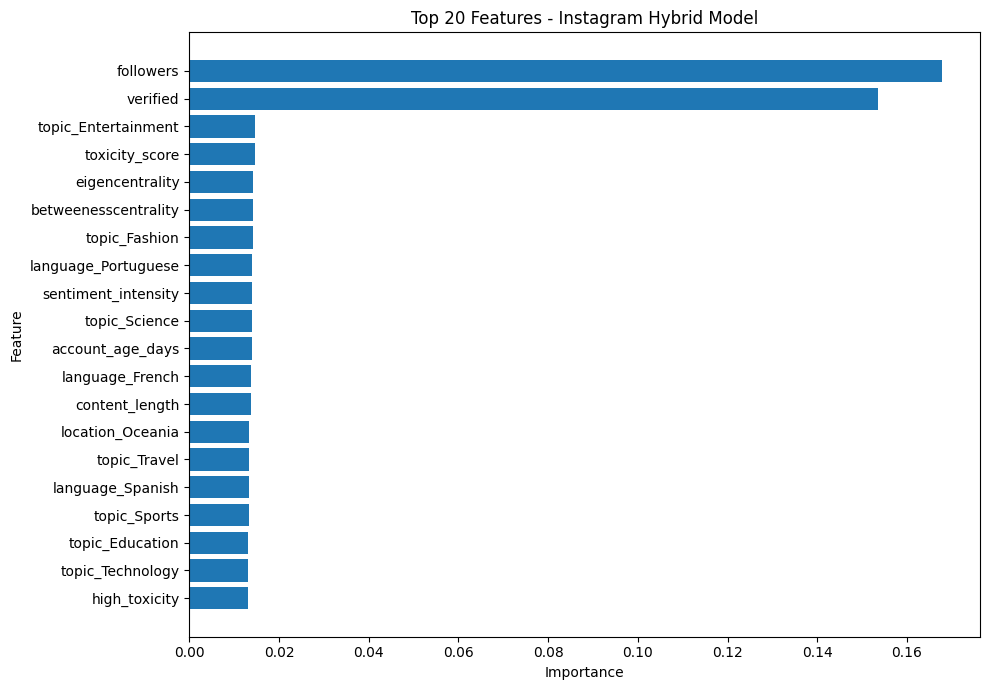

In [114]:
# PLOT TOP FEATURES
# =====================================================
import matplotlib.pyplot as plt

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Features - Instagram Hybrid Model"
)

plt.tight_layout()

plt.show()

# 2. INSTAGRAM NODE2VEC

 GRAPH EMBEDDING

In [71]:
import pandas as pd
import os
import networkx as nx

import time

start_time = time.time()

# 1. CHỈ CẦN NẠP EDGES LÀ ĐỦ
# =====================================================
print("Đang nạp file Edges...")
edges_df = pd.read_csv("insta_edge.csv") # Đổi tên file cho đúng với của bạn nhé

# 2. XÂY DỰNG GRAPH SIÊU TỐC TRONG 1 GIÂY (Không dùng iterrows)
# =====================================================
print("Đang xây dựng NetworkX Graph...")
# Hàm này của NetworkX tự động nạp toàn bộ edges và sinh ra Nodes cực nhanh
G = nx.from_pandas_edgelist(
    edges_df, 
    source="Source", 
    target="Target", 
    create_using=nx.Graph() # Đảm bảo là Đồ thị vô hướng (Undirected)
)

print(f"Graph Created 🚀 | Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}")

# 3. CHẠY NODE2VEC (TỐI ƯU TỐC ĐỘ VÀ CHỐNG OVERFITTING)
# =====================================================
print("TRAINING NODE2VEC (MULTI-CORE)...")


# 1. Tự động đếm số lượng lõi CPU trên máy của bà
so_loi_cpu = os.cpu_count()
print(f"👉 Máy của bà đang có {so_loi_cpu} lõi CPU. Đang huy động toàn bộ...")

print("\n" + "=" * 60)
print("TRAINING NODE2VEC (MULTI-CORE CẬP NHẬT)...")
print("=" * 60)



Đang nạp file Edges...
Đang xây dựng NetworkX Graph...
Graph Created 🚀 | Nodes: 30,195 | Edges: 108,162
TRAINING NODE2VEC (MULTI-CORE)...
👉 Máy của bà đang có 22 lõi CPU. Đang huy động toàn bộ...

TRAINING NODE2VEC (MULTI-CORE CẬP NHẬT)...


In [72]:
from node2vec import Node2Vec
import time
# 2. Truyền con số dương vào tham số workers
node2vec = Node2Vec(
    G,
    dimensions=8,        # Giữ nguyên 8 chiều để XGBoost không ngộp
    walk_length=10,      
    num_walks=20,        
    workers=so_loi_cpu,  # <--- BÍ KÍP ĐÃ ĐƯỢC SỬA Ở ĐÂY
    seed=42,
    quiet=False          
)

model = node2vec.fit(
    window=5, 
    min_count=1, 
    batch_words=4     
)

print("\nNode2Vec hoàn thành 🚀")

print(f"\nNode2Vec hoàn thành sau: {round((time.time() - start_time)/60, 2)} phút 🚀")



Computing transition probabilities:   0%|          | 0/30195 [00:00<?, ?it/s]


Node2Vec hoàn thành 🚀

Node2Vec hoàn thành sau: 11.72 phút 🚀


In [73]:
# 4. TRÍCH XUẤT VÀ LƯU VECTOR RA FILE CSV ĐỂ MERGE
# =====================================================
print("Đang xuất Embeddings ra DataFrame...")

# Trích xuất ID của Node và 8 cột Vector
node_ids = list(model.wv.index_to_key)
embeddings = model.wv.vectors

# Tạo DataFrame
emb_df = pd.DataFrame(embeddings, columns=[f"emb_{i}" for i in range(8)])
emb_df["post_id"] = node_ids # Cột này cực kỳ quan trọng để lát nữa merge với tập Train/Test

# LỌC BỎ CÁC TRẠM HUBS (TOPIC, LANG...):
# Vì trong danh sách node có cả "TOPIC_Sports", ta chỉ lấy những dòng có dạng "INS..." (là bài Post)
emb_df = emb_df[emb_df['post_id'].astype(str).str.startswith('INS')]

# Lưu ra file CSV
emb_df.to_csv("instagram_node2vec_8dims.csv", index=False)
print(f"Đã lưu thành công {len(emb_df)} vectors của bài Post!")

Đang xuất Embeddings ra DataFrame...
Đã lưu thành công 30195 vectors của bài Post!


In [115]:
# FACEBOOK NODE2VEC HYBRID MODEL
# METADATA + NODE2VEC EMBEDDINGS
# =====================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt

In [163]:
# LOAD TRAIN / TEST DATA
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/instagram_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/instagram_test.csv"
)

print("=" * 60)
print("METADATA DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATA
Train Shape: (24156, 56)
Test Shape : (6039, 56)


In [200]:
#LOAD NODE2VEC EMBEDDINGS
# =====================================================

embedding_df = pd.read_csv(
    "instagram_node2vec_8dims.csv"
)

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

print("\nEmbedding Columns:")
print(embedding_df.columns[:10])


NODE2VEC EMBEDDINGS
(30195, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='str')


In [164]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# CHECK MISSING VALUES
# =====================================================

print("\n" + "=" * 60)
print("MISSING EMBEDDINGS CHECK")
print("=" * 60)

embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nTrain Missing:")

print(
    train_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nTest Missing:")

print(
    test_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

# =====================================================
# FILL MISSING EMBEDDINGS
# =====================================================

train_hybrid[embedding_cols] = train_hybrid[
    embedding_cols
].fillna(0)

test_hybrid[embedding_cols] = test_hybrid[
    embedding_cols
].fillna(0)

# =====================================================
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_hybrid.columns
]

train_hybrid = train_hybrid.drop(
    columns=existing_drop_cols
)

test_hybrid = test_hybrid.drop(
    columns=existing_drop_cols
)


MISSING EMBEDDINGS CHECK

Train Missing:
0.0

Test Missing:
0.0


In [165]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_hybrid.drop(
    columns=["popularity"]
)

y_train = train_hybrid["popularity"]

X_test = test_hybrid.drop(
    columns=["popularity"]
)

y_test = test_hybrid["popularity"]

print("\n" + "=" * 60)
print("FINAL DATA")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)



FINAL DATA
X_train: (24156, 61)
X_test : (6039, 61)


In [166]:
# =====================================================
# XGBOOST MODEL
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    
    # ⚖️ Vẫn giữ Ratio cũ của bà
    scale_pos_weight=ratio,      
    
    # 🌲 TĂNG ĐỘ SÂU ĐỂ HỌC GRAPH
    n_estimators=400,            # Tăng nhẹ số cây
    learning_rate=0.03,          # Giảm học phí xuống chút để học kỹ hơn
    max_depth=7,                 # Tăng từ 5 lên 7 (Cực kỳ quan trọng)
    
    # 🛡️ CHỐNG OVERFIT (Bà giữ bộ khung này rất tốt)
    subsample=0.8,               
    colsample_bytree=0.7,        
    reg_alpha=0.5,               
    reg_lambda=1.5,              
    
    random_state=42,
    n_jobs=-1
)
# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING NODE2VEC HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("Training completed 🚀")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

# =====================================================
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


TRAINING NODE2VEC HYBRID MODEL...
Training completed 🚀


In [176]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      4828
           1       0.51      0.72      0.60      1211

    accuracy                           0.81      6039
   macro avg       0.72      0.77      0.73      6039
weighted avg       0.84      0.81      0.82      6039

ROC-AUC  : 0.8645


In [168]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                feature  importance
3             followers    0.195310
5              verified    0.117385
50     location_Oceania    0.014876
41  language_Portuguese    0.013766
24        topic_Fashion    0.013760
20       topic_Business    0.013343
33         topic_Travel    0.013016
10       toxicity_score    0.013012
4      account_age_days    0.012986
8    sentiment_positive    0.012916
9    sentiment_negative    0.012912
58                emb_5    0.012901
25        topic_Finance    0.012774
18  sentiment_intensity    0.012739
53                emb_0    0.012728
54                emb_1    0.012725
59                emb_6    0.012621
22      topic_Education    0.012567
57                emb_4    0.012540
56                emb_3    0.012526


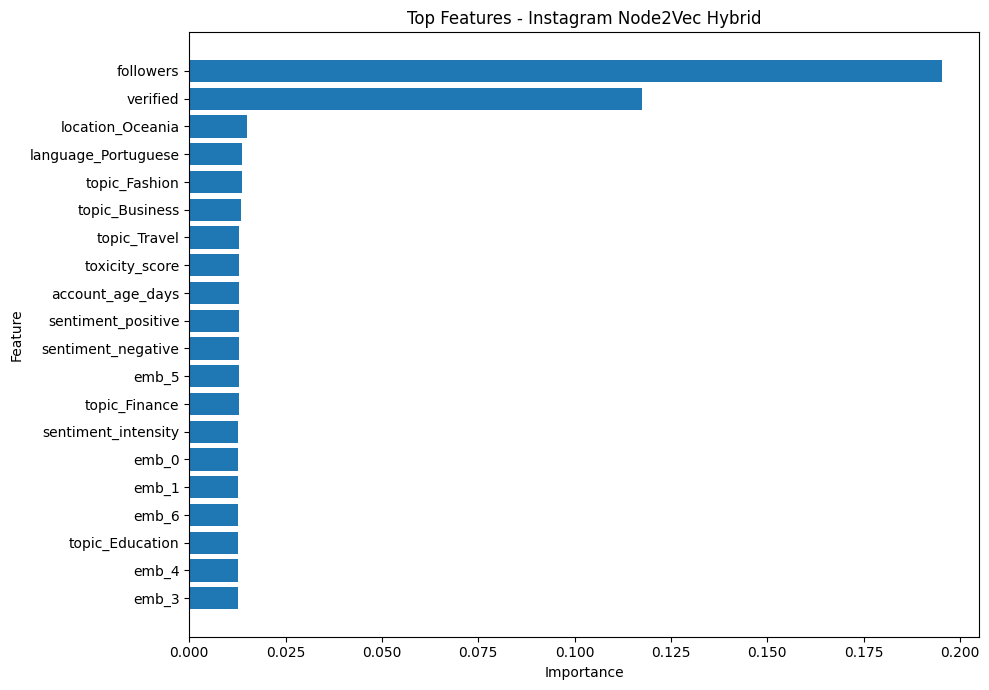

In [217]:
# =====================================================

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Features - Instagram Node2Vec Hybrid"
)

plt.tight_layout()

plt.show()

# 3. Instagram graph + Node2vector

In [201]:
# 1. Xác định các cột n2v có Importance cao nhất từ kết quả mới của bạn
# Chốt danh sách emb_ xịn (Bà bảo của bà là emb_ nên tui sửa lại hết thành emb_ nha)
selected_n2v = ["emb_0", "emb_6", "emb_3", "emb_4", "emb_1"]

# Chỉ giữ lại post_id và các cột đã chọn để tránh làm nặng model
embedding_df_filtered = embedding_df[["post_id"] + [c for c in selected_n2v if c in embedding_df.columns]]

print("--- ✅ Đã lọc Embedding tinh gọn ---")
print(f"Các cột sẽ dùng: {embedding_df_filtered.columns.tolist()}")

--- ✅ Đã lọc Embedding tinh gọn ---
Các cột sẽ dùng: ['post_id', 'emb_0', 'emb_6', 'emb_3', 'emb_4', 'emb_1']


In [202]:
train_df = pd.read_csv(
    "instagram_hybrid_train.csv"
)

test_df = pd.read_csv(
    "instagram_hybrid_test.csv"
)

print("=" * 60)
print("GRAPH HYBRID DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# =====================================================
# LOAD NODE2VEC EMBEDDINGS
# =====================================================

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

# =====================================================
# CHECK EMBEDDING KEY
# =====================================================

print("\nEmbedding Columns:")
print(embedding_df.columns)


GRAPH HYBRID DATA
Train Shape: (24156, 61)
Test Shape : (6039, 61)

NODE2VEC EMBEDDINGS
(30195, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='str')


In [203]:
# 2. MERGE VÀO DATA HYBRID
# =====================================================
# Merge vào tập Train
train_final = train_df.merge(embedding_df_filtered, on="post_id", how="left")

# Merge vào tập Test
test_final = test_df.merge(embedding_df_filtered, on="post_id", how="left")

print(f"\n--- ✅ Đã Merge xong ---")
print(f"Train Shape: {train_final.shape} | Test Shape: {test_final.shape}")


--- ✅ Đã Merge xong ---
Train Shape: (24156, 66) | Test Shape: (6039, 66)


In [204]:
# 3. XỬ LÝ MISSING VALUES (FIX "RÂU ÔNG NỌ" Ở ĐÂY)
# =====================================================
# Bà phải tìm cột bắt đầu bằng "emb_" chứ không phải "n2v_" nè!
actual_emb_cols = [col for col in train_final.columns if col.startswith("emb_")]

print(f"\n🔍 Đang kiểm tra Missing cho {len(actual_emb_cols)} cột embedding...")

# Điền 0 cho những bài post "cô đơn" (không có kết nối graph)
train_final[actual_emb_cols] = train_final[actual_emb_cols].fillna(0)
test_final[actual_emb_cols] = test_final[actual_emb_cols].fillna(0)

print(f"Missing sau khi fill: {train_final[actual_emb_cols].isnull().sum().sum()}")


🔍 Đang kiểm tra Missing cho 5 cột embedding...
Missing sau khi fill: 0


In [205]:
# =====================================================
# 4. DỌN DẸP ID (DROP CÁC CỘT KHÔNG DÙNG ĐỂ TRAIN)
# =====================================================
drop_cols = ["post_id", "user_id"]
existing_drop_cols = [col for col in drop_cols if col in train_final.columns]

train_final = train_final.drop(columns=existing_drop_cols)
test_final = test_final.drop(columns=existing_drop_cols)

print(f"\n--- 🚀 HOÀN TẤT ---")
print(f"Dữ liệu cuối cùng: {train_final.shape[1]} features.")


--- 🚀 HOÀN TẤT ---
Dữ liệu cuối cùng: 64 features.


In [206]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_final.drop(
    columns=["popularity"]
)

y_train = train_final["popularity"]

X_test = test_final.drop(
    columns=["popularity"]
)

y_test = test_final["popularity"]

print("\n" + "=" * 60)
print("FINAL FEATURE SPACE")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


FINAL FEATURE SPACE
X_train: (24156, 63)
X_test : (6039, 63)


In [213]:
# XGBOOST MODEL
# =====================================================

# XGBOOST MODEL
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    
    # ⚖️ Vẫn giữ Ratio cũ của bà
    scale_pos_weight=ratio,      
    
    # 🌲 TĂNG ĐỘ SÂU ĐỂ HỌC GRAPH
    n_estimators=400,            # Tăng nhẹ số cây
    learning_rate=0.03,          # Giảm học phí xuống chút để học kỹ hơn
    max_depth=7,                 # Tăng từ 5 lên 7 (Cực kỳ quan trọng)
    
    # 🛡️ CHỐNG OVERFIT (Bà giữ bộ khung này rất tốt)
    subsample=0.8,               
    colsample_bytree=0.7,        
    reg_alpha=0.5,               
    reg_lambda=1.5,              
    
    random_state=42,
    n_jobs=-1
)

# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING FINAL INSTAGRAM META + GRAPH + EMBEDDING...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("\nTraining completed 🚀")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


TRAINING FINAL INSTAGRAM META + GRAPH + EMBEDDING...

Training completed 🚀


In [214]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


In [215]:


# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      4828
           1       0.50      0.71      0.59      1211

    accuracy                           0.80      6039
   macro avg       0.71      0.77      0.73      6039
weighted avg       0.83      0.80      0.81      6039

ROC-AUC  : 0.8648


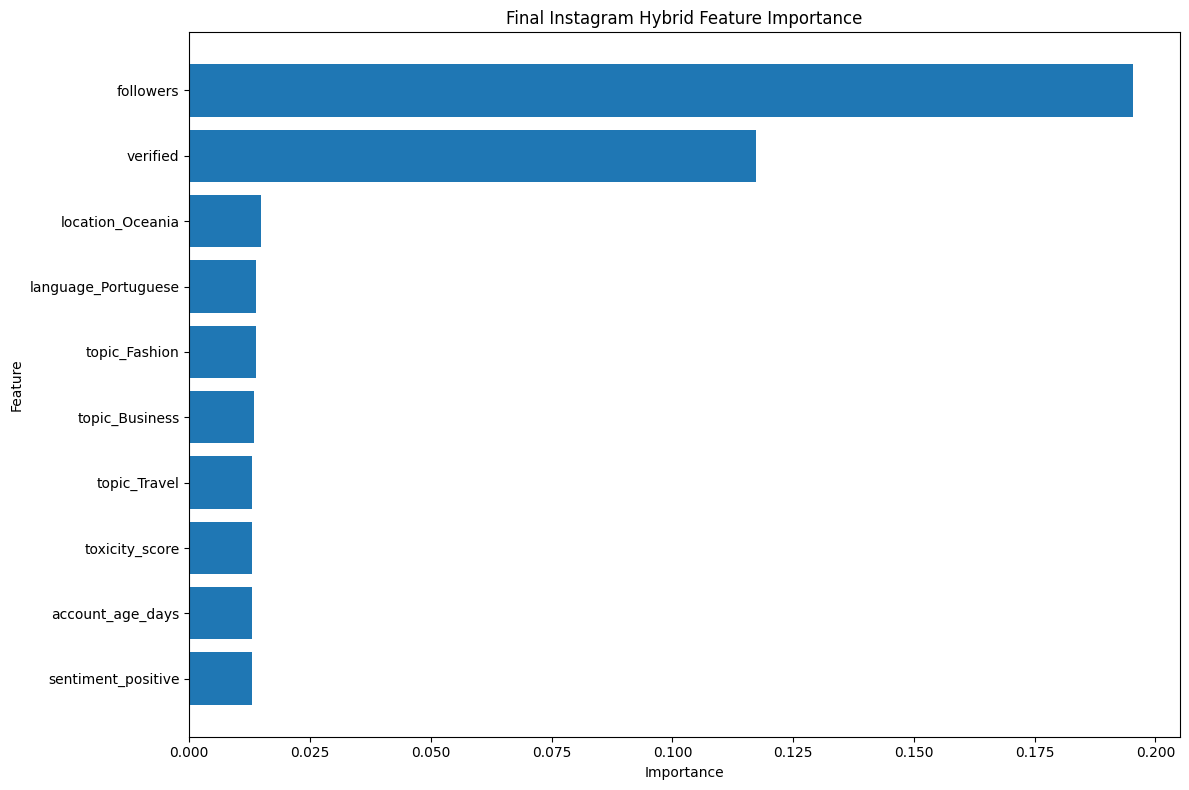

In [216]:
# PLOT FEATURE IMPORTANCE
# =====================================================

top_n = 10

plot_df = importance_df.head(top_n)

plt.figure(figsize=(12, 8))

plt.barh(

    plot_df["feature"][::-1],

    plot_df["importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Final Instagram Hybrid Feature Importance"
)

plt.tight_layout()

plt.show()